In [58]:
import sys
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

REPO_ROOT = Path("..").resolve()
sys.path.append(str(REPO_ROOT / "src"))

import utils


## 1. Data Loading

In [59]:
features, universe, returns = utils.load_data()

print("features:", features.shape, " (rows=dates, columns=(feature, stock_id))")
print("universe:", universe.shape)
print("returns: ", returns.shape)


features: (5058, 47674)  (rows=dates, columns=(feature, stock_id))
universe: (5058, 2167)
returns:  (3775, 2167)


In [60]:
print("\nFeatures columns:")
print(features.columns[:10])

print("\nFeatures head:")
display(features.head())

print("\nUniverse head:")
display(universe.head())

print("\nReturns head:")
display(returns.head())


Features columns:
MultiIndex([('macd',  1),
            ('macd',  2),
            ('macd',  3),
            ('macd',  4),
            ('macd',  5),
            ('macd',  6),
            ('macd',  7),
            ('macd',  8),
            ('macd',  9),
            ('macd', 10)],
           )

Features head:


macd                                                         \
                1         2    3         4         5         6    7    8      
Date                                                                          
2005-01-03  0.000000  0.000000  NaN  0.000000  0.000000  0.000000  NaN  NaN   
2005-01-04 -0.004732 -0.013272  NaN -0.000149 -0.002068  0.000122  NaN  NaN   
2005-01-05 -0.007316 -0.024657  NaN -0.000298 -0.002582  0.000294  NaN  NaN   
2005-01-06 -0.012633 -0.029492  NaN -0.000696 -0.003024  0.000432  NaN  NaN   
2005-01-07 -0.017653 -0.024735  NaN -0.001319 -0.005041  0.001372  NaN  NaN   

                                ... chande_momentum_oscillator                 \
                9         10    ...                       2158 2159 2160 2161   
Date                            ...                                             
2005-01-03  0.000000  0.000000  ...                        NaN  NaN  NaN  NaN   
2005-01-04 -0.002817 -0.000112  ...                        NaN  NaN  NaN  NaN   
2005-01-05 -0.009337  0.002122  ...                        NaN  NaN  NaN  NaN   
2005-01-06 -0.011318  0.005346  ...                        NaN  NaN  NaN  NaN   
2005-01-07 -0.013881  0.009659  ...                        NaN  NaN  NaN  NaN   

                                          
           2162 2163 2164 2165 2166 2167  
Date                                      
2005-01-03  NaN  NaN  NaN  NaN  NaN  NaN  
2005-01-04  NaN  NaN  NaN  NaN  NaN  NaN  
2005-01-05  NaN  NaN  NaN  NaN  NaN  NaN  
2005-01-06  NaN  NaN  NaN  NaN  NaN  NaN  
2005-01-07  NaN  NaN  NaN  NaN  NaN  NaN  

[5 rows x 47674 columns]


Universe head:


,1,2,3,4,5,6,7,8,9,10,...,2158,2159,2160,2161,2162,2163,2164,2165,2166,2167
Date,,,,,,,,,,,,,,,,,,,,,
2005-01-03,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2005-01-04,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2005-01-05,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2005-01-06,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2005-01-07,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0



Returns head:


,1,2,3,4,5,6,7,8,9,10,...,2158,2159,2160,2161,2162,2163,2164,2165,2166,2167
Date,,,,,,,,,,,,,,,,,,,,,
2005-01-03,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,...,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
2005-01-04,-0.026382,-0.018070,0.0,-0.007328,-0.006659,0.010270,0.0,0.0,-0.017553,-0.000721,...,0.005948,0.0,-0.013652,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
2005-01-05,-0.000430,-0.005916,0.0,-0.003356,0.001849,0.008758,0.0,0.0,-0.031265,0.014430,...,-0.011431,0.0,-0.003611,0.0,0.0,0.0,0.0,0.0,0.0,-0.133331
2005-01-06,-0.021945,0.004298,0.0,-0.014815,-0.000923,0.000775,0.0,0.0,0.021004,0.008535,...,-0.000797,0.0,0.005738,0.0,0.0,0.0,0.0,0.0,0.0,0.038462
2005-01-07,-0.000880,0.010204,0.0,-0.012987,-0.005774,0.072811,0.0,0.0,-0.014049,0.009873,...,-0.003991,0.0,-0.024321,0.0,0.0,0.0,0.0,0.0,0.0,0.000000


In [61]:
print(features.columns.levels[0].tolist())

['accumulation_distribution_index', 'aroon', 'average_true_range', 'chaikin_money_flow', 'chande_momentum_oscillator', 'commodity_channel_index', 'ease_of_movement', 'ichimoku', 'know_sure_thing', 'macd', 'on_balance_volume', 'relative_strength_index', 'stochastic_oscillator', 'trend_1_3', 'trend_20_60', 'trend_5_20', 'trix', 'ultimate_oscillator', 'volatility_20', 'volatility_60', 'volume', 'williams_r']


We have 22 features which can be grouped in the following categories:

(a) Trend/Momentum: trend_1_3, trend_5_20, trend_20_60, macd, trix, know_sure_thing, aroon

(b) Mean Reversion: relative_strength_index, williams_r, stochastic_oscillator, commodity_channel_index, ultimate_oscillator, chande_momentum_oscillator

(c) Volume/Money Flow: chaikin_money_flow, on_balance_volume, accumulation_distribution_index, ease_of_movement, volume

(d) Risk: volatility_20, volatility_60, average_true_range

(e) Miscellaneous: ichimoku

## 2. Strategy Implementation

In [62]:
target_returns = returns.shift(-1) # Next day's returns

for feature_name in features.columns.levels[0]:
    feature_data = features[feature_name]
    
    # Calculate daily cross-sectional correlation
    daily_ic = feature_data.corrwith(target_returns, axis=1, method='spearman')
    print(f"{feature_name:30s} Mean IC: {daily_ic.mean():.4f}")

# target_returns = returns.shift(-1)

# daily_ic_df = pd.DataFrame(index=features.index)

# for feature_name in features.columns.levels[0]:
#     feature_data = features[feature_name]

#     daily_ic = feature_data.corrwith(
#         target_returns,
#         axis=1,
#         method="spearman"
#     )

#     daily_ic_df[feature_name] = daily_ic
    
#     print(f"{feature_name:30s} Mean IC: {daily_ic.mean():.4f}")

# global_ic = daily_ic_df.mean()
# global_sign = np.sign(global_ic)
# global_sign[global_sign == 0] = 1

# # Adaptive rolling IC (Corrected for lookahead bias)
# rolling_ic = (
#     daily_ic_df
#     .ewm(span=60, min_periods=20, adjust=False)
#     .mean()
#     .shift(1) # CRITICAL: Shifts the dataframe down by 1 day
# )

# rolling_mean = (
#     daily_ic_df
#     .ewm(span=60, min_periods=20, adjust=False)
#     .mean()
# )

# rolling_std = (
#     daily_ic_df
#     .ewm(span=60, min_periods=20, adjust=False)
#     .std()
# )

# rolling_ir = (
#     rolling_mean / (rolling_std + 1e-6)
# ).shift(1)

accumulation_distribution_index Mean IC: -0.0080
aroon                          Mean IC: 0.0003
average_true_range             Mean IC: -0.0075
chaikin_money_flow             Mean IC: -0.0042
chande_momentum_oscillator     Mean IC: -0.0076
commodity_channel_index        Mean IC: -0.0075
ease_of_movement               Mean IC: -0.0066
ichimoku                       Mean IC: -0.0005
know_sure_thing                Mean IC: 0.0000


/opt/miniconda3/lib/python3.13/site-packages/pandas/core/nanops.py:1632: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return spearmanr(a, b)[0]


macd                           Mean IC: 0.0016
on_balance_volume              Mean IC: 0.0095


/opt/miniconda3/lib/python3.13/site-packages/pandas/core/nanops.py:1632: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return spearmanr(a, b)[0]


relative_strength_index        Mean IC: -0.0164
stochastic_oscillator          Mean IC: -0.0159
trend_1_3                      Mean IC: -0.0143
trend_20_60                    Mean IC: -0.0196
trend_5_20                     Mean IC: -0.0222
trix                           Mean IC: 0.0017
ultimate_oscillator            Mean IC: -0.0125
volatility_20                  Mean IC: -0.0010
volatility_60                  Mean IC: -0.0013
volume                         Mean IC: 0.0139
williams_r                     Mean IC: -0.0159


Our strongest trend features (trend_5_20 with an IC of -0.0222 and trend_20_60 with an IC of -0.0196) have deeply negative predictive correlations. This means stocks that have been trending up over the last month systematically sell off tomorrow, and vice versa. Meanwhile, raw volume (+0.0139) and on_balance_volume (+0.0095) provide positive confirmation.

In [ ]:
# ITERATION-1
# def get_weights(features: pd.DataFrame, today_universe: pd.Series) -> dict[str, float]:
#     tradable = today_universe[today_universe == 1].index
#     if len(tradable) < 20:
#         return {}

#     # Smooth features over a short 3-day window to balance noise
#     latest = features.iloc[-3:].mean()

#     def rank_norm(x):
#         return x.rank(pct=True, na_option='keep') - 0.5
    
#     # IC-Weighted Multi-Factor Al   pha Score
#     # Positive IC features get a positive sign; Negative IC features get a negative sign.
#     # The magnitude of the weight is proportional to the strength of the IC.
#     score = (
#         - 0.0222 * rank_norm(latest["trend_5_20"])
#         - 0.0196 * rank_norm(latest["trend_20_60"])
#         - 0.0164 * rank_norm(latest["relative_strength_index"])
#         - 0.0159 * rank_norm(latest["stochastic_oscillator"])
#         - 0.0159 * rank_norm(latest["williams_r"])
#         - 0.0143 * rank_norm(latest["trend_1_3"])
#         + 0.0139 * rank_norm(latest["volume"])
#         - 0.0125 * rank_norm(latest["ultimate_oscillator"])
#         + 0.0095 * rank_norm(latest["on_balance_volume"])
#         - 0.0080 * rank_norm(latest["accumulation_distribution_index"])
#         - 0.0076 * rank_norm(latest["chande_momentum_oscillator"])
#         - 0.0075 * rank_norm(latest["commodity_channel_index"])
#         - 0.0075 * rank_norm(latest["average_true_range"])
#         - 0.0066 * rank_norm(latest["ease_of_movement"])
#         - 0.0042 * rank_norm(latest["chaikin_money_flow"])
#         + 0.0017 * rank_norm(latest["trix"])
#         + 0.0016 * rank_norm(latest["macd"])
#     )

#     # Volatility-Adjusted Alpha for Risk Control
#     risk = (latest["volatility_20"].fillna(0) + latest["volatility_60"].fillna(0)) / 2
#     score = score / np.sqrt(risk.clip(lower=1e-4))
    
#     score = score.loc[tradable].dropna()
    
#     # Center the scores to guarantee strict Dollar Neutrality 
#     score = score - score.mean()
    
#     # Scale scores so total gross exposure equals 1.0 
#     weights = score / score.abs().sum()
    
#     # Enforce Max Weight limit constraint (0.1)
#     weights = weights.clip(-0.1, 0.1)
    
#     # Final re-normalization to fix shifts caused by the clipping step
#     weights = weights / weights.abs().sum()

#     return weights.to_dict()

# ITERATION-2
# def get_weights(features: pd.DataFrame, today_universe: pd.Series) -> dict[str, float]:

#     alpha_factors = [
#     "trend_5_20",
#     "trend_20_60",
#     "relative_strength_index",
#     "stochastic_oscillator",
#     "williams_r",
#     "trend_1_3",
#     "volume",
#     "ultimate_oscillator",
#     "on_balance_volume",
#     "accumulation_distribution_index",
#     "chande_momentum_oscillator",
#     "commodity_channel_index",
#     "average_true_range",
#     "ease_of_movement",
#     "chaikin_money_flow",
#     "trix",
#     "macd",
#     ]

#     tradable = today_universe[today_universe == 1].index
#     if len(tradable) < 20:
#         return {}

#     today = features.index[-1]

#     latest = features.iloc[-3:].mean()
#     latest = latest.unstack(level=0)

#     def rank_norm(x):
#         return x.rank(pct=True, na_option="keep") - 0.5

#     # # ICs available before today's trade
#     # rolling = rolling_ic.loc[today, alpha_factors].fillna(0)

#     # # Keep the original direction, adapt only the magnitude
#     # ic = global_sign.loc[alpha_factors] * rolling.abs()

#     ir = rolling_ir.loc[today, alpha_factors].fillna(0)
#     ic = global_sign.loc[alpha_factors] * ir.abs()

#     if ic.abs().sum() == 0:
#         return {}

#     ic = ic / ic.abs().sum()

#     score = pd.Series(0.0, index=latest.index)

#     for factor in alpha_factors:
#         score += ic[factor] * rank_norm(latest[factor])

#     # Risk adjustment
#     risk = (
#         latest["volatility_20"].fillna(0)
#         + latest["volatility_60"].fillna(0)
#     ) / 2

#     score = score / np.sqrt(risk.clip(lower=1e-4))

#     score = score.loc[tradable].dropna()

#     if len(score) == 0:
#         return {}

#     # Dollar neutrality
#     score = score - score.mean()

#     # Gross leverage = 1
#     weights = score / score.abs().sum()

#     # Position limits
#     weights = weights.clip(-0.1, 0.1)

#     # Re-normalize
#     weights = weights / weights.abs().sum()
    
#     return weights.to_dict()


In [ ]:
# ITERATION-3
def get_weights(features: pd.DataFrame, today_universe: pd.Series) -> dict[str, float]:
    tradable = today_universe[today_universe == 1].index
    if len(tradable) < 20:
        return {}

    # 1. 10-day EMA instead of a 3-day Simple Average.  This smooths the daily noise in the factors, introducing "inertia" to your positions
    latest = features.iloc[-15:].ewm(span=10, min_periods=1).mean().iloc[-1]
    latest = latest.unstack(level=0)

    def rank_norm(x):
        return x.rank(pct=True, na_option='keep') - 0.5
    
    # Using baseline Global IC weighting
    score = (
        - 0.0222 * rank_norm(latest["trend_5_20"])
        - 0.0196 * rank_norm(latest["trend_20_60"])
        - 0.0164 * rank_norm(latest["relative_strength_index"])
        - 0.0159 * rank_norm(latest["stochastic_oscillator"])
        - 0.0159 * rank_norm(latest["williams_r"])
        - 0.0143 * rank_norm(latest["trend_1_3"])
        + 0.0139 * rank_norm(latest["volume"])
        - 0.0125 * rank_norm(latest["ultimate_oscillator"])
        + 0.0095 * rank_norm(latest["on_balance_volume"])
        - 0.0080 * rank_norm(latest["accumulation_distribution_index"])
        - 0.0076 * rank_norm(latest["chande_momentum_oscillator"])
        - 0.0075 * rank_norm(latest["commodity_channel_index"])
        - 0.0075 * rank_norm(latest["average_true_range"])
        - 0.0066 * rank_norm(latest["ease_of_movement"])
        - 0.0042 * rank_norm(latest["chaikin_money_flow"])
        + 0.0017 * rank_norm(latest["trix"])
        + 0.0016 * rank_norm(latest["macd"])
    )

    # Volatility-Adjusted Alpha for Risk Control
    risk = (latest["volatility_20"].fillna(0) + latest["volatility_60"].fillna(0)) / 2
    score = score / np.sqrt(risk.clip(lower=1e-4))
    score = score.loc[tradable].dropna()
    
    if len(score) == 0:
        return {}
    
    # Center the scores to start at zero
    score = score - score.mean()
    
    # 2. STRICT DOLLAR NEUTRALITY FIX
    # Separate longs and shorts so clipping one side doesn't unbalance the portfolio
    longs = score[score > 0]
    shorts = score[score < 0]
    
    # Scale each side to represent exactly 0.5 gross exposure (total 1.0)
    longs = longs / longs.sum() * 0.5
    shorts = shorts / shorts.abs().sum() * -0.5
    
    # Enforce Max Weight limit constraint (0.1)
    longs = longs.clip(upper=0.1)
    shorts = shorts.clip(lower=-0.1)
    
    # Final re-normalization specifically per side to fix any shifts caused by clipping
    longs = longs / longs.sum() * 0.5
    shorts = shorts / shorts.abs().sum() * -0.5

    # Combine back into a single weight series
    weights = pd.concat([longs, shorts])

    return weights.to_dict()

## 3. Backtest

In [64]:
weights = utils.backtest_strategy(get_weights, features, universe)
weights.head()


Backtesting: 100%|██████████| 5058/5058 [36:12<00:00,  2.33it/s]


,1,2,3,4,5,6,7,8,9,10,...,2158,2159,2160,2161,2162,2163,2164,2165,2166,2167
Date,,,,,,,,,,,,,,,,,,,,,
2005-01-03,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2005-01-04,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2005-01-05,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2005-01-06,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2005-01-07,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## 4. Constraint Validation

In [66]:
checks = utils.validate_weights(weights, universe)
for name, passed in checks.items():
    print(f"{name:20s} {'PASS' if passed else 'FAIL'}")


unit_capital         PASS
max_weight           PASS
dollar_neutral       PASS
universe_respected   PASS


## 5. Strategy Scoring

In [67]:
metrics = utils.summarize_performance(weights, returns)
for k, v in metrics.items():
    print(f"{k:16s} {v:.4f}")


turnover_pct     29.5753
gross_sharpe     1.1837
net_sharpe       1.0135
mean_book_value  0.9913


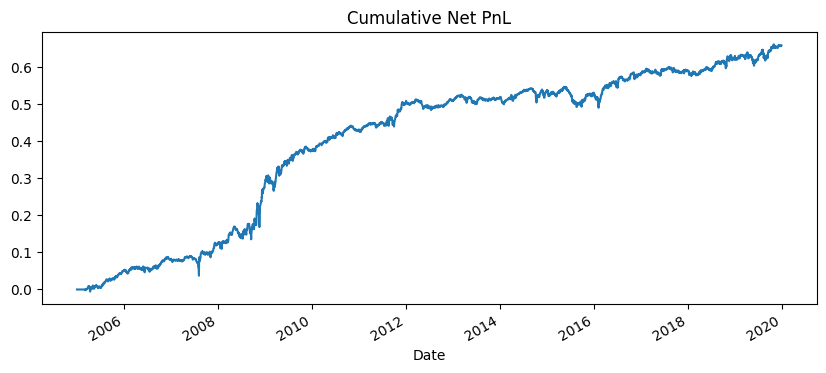

In [68]:
net_pnl = utils.net_pnl(weights, returns)
net_pnl.cumsum().plot(figsize=(10, 4), title="Cumulative Net PnL")
plt.show()


## 6. Exporting submission

`submission.csv` is saved to the repo root and must have the same shape and
index as `data/universe.parquet`. Run `src/validate_submission.py` from the
repo root to double check before you submit (see `docs/submission_format.md`).


In [70]:
output_path = REPO_ROOT / "submission.csv"
weights.to_csv(output_path)
print("Saved", output_path, "with shape", weights.shape)

Saved /Users/sourishsrivastava/Documents/GitHub/CSOT-Quant/week-3/Week 3/submission.csv with shape (5058, 2167)
